# Task 2 & 3 — Feature Representations and Review Classification

## Table of Contents

1. [Import Libraries](#1-import-lib)
2. [Helper Functions](#2-helper-functions)
   - 2.1 [Constants & Paths](#constants--paths)
   - 2.2 [Core Functions](#core-functions)
3. [Task 2: Generating Feature Representations](#3-task-2-generating-feature-representations-for-cosmeticsbeauty-reviews)
4. [Task 3: Cosmetics/Beauty Products Review Classification](#4-task-3-cosmeticsbeauty-products-review-classification)
   - 4.1 [Class imbalance and `class_weight`](#class-imbalance-and-why-class_weightbalanced-is-used)
   - 4.2 [Q1: Language model comparisons](#q1-language-model-comparisons)
   - 4.3 [Conclusion: Model/Representation Comparison](#conclusion-modelrepresentation-comparison)
   - 4.4 [Q2: Does more information provide higher accuracy](#q2-does-more-information-provide-higher-accuracy)
     - [P1: Adding description/text and title](#p1-adding-descriptiontext-and-title-of-the-review)
     - [P2: Adding extra information](#p2-adding-extra-information)
       - [Numeric columns evaluation](#numeric-columns-evaluation)
       - [Categorical columns evaluation](#categorical-columns-evaluation)
       - [High-dimensional text](#high-dimensional-text)
       - [Conclusion of attribute selection](#conclusion-of-attribute-selection)
     - [Conclusion Q2](#conclusion-q2)

---

## Installation

> **Requires Python 3.10+**

```bash
pip install pandas numpy matplotlib seaborn scikit-learn scipy gensim
```

Or if you are using `uv` / `pyproject.toml`:

```bash
uv pip install pandas numpy matplotlib seaborn scikit-learn scipy gensim
```

There are no separate corpus downloads required for this notebook (unlike Task 1 NLTK data). Ensure `./data/` contains the outputs from Task 1 (`processed.csv`, `vocab.txt`, etc.) before running the Task 2 pipeline cells.

# 1. Import Lib

In [ ]:
# Code to import libraries as you need in this assessment, e.g.,
import pandas as pd
import re
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import KeyedVectors
from scipy.sparse import coo_matrix, issparse, csr_matrix
import warnings
warnings.filterwarnings("ignore")
from gensim.models import FastText
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import f_classif, mutual_info_classif
from scipy.stats import mannwhitneyu, chi2_contingency
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

# 2. Helper Functions

## Constants & Paths

In [116]:
VOCAB_PATH = "./data/vocab.txt"
DATASET_PATH = "./data/processed.csv"
STOPWORDS_ENHANCEMENT_PATH = "./data/stopwords_en_enhancement.txt"
BOW_PATH = "./data/count_vectors.txt"
UNWEIGHTED_PATH = "./data/unweighted_vectors.txt"
WEIGHTED_PATH = "./data/weighted_vectors.txt"
GLOVE_PATH = "/Users/nhan.ngo/rmit/RMIT-Advanced-Programming-for-Data-Science/archive/glove.6B.300d.txt"
OUTPUT_PATH = "./data/unweighted_vectors.txt"

## Core Functions

In [130]:
TOKENIZER_PATTERN = re.compile(r"[a-zA-Z]+(?:[-'][a-zA-Z]+)?") # the regex pattern to split the text into tokens


def _split_tokens(text: str) -> list[str]:
    """Split raw text into alphabetic tokens.

    Args:
        text: Input text to tokenize.

    Returns:
        List of regex-matched tokens.
    """
    # Apply the compiled regex to extract alphabetic tokens (allows internal hyphens/apostrophes)
    return TOKENIZER_PATTERN.findall(str(text))


with open(STOPWORDS_ENHANCEMENT_PATH, encoding="utf-8") as _sf:
    _stop_enh: set[str] = {line.strip().lower() for line in _sf if line.strip()}


def _tfidf_analyzer(doc: str) -> list[str]:
    """Tokenize like Task 1, then drop enhanced English stopwords before TF-IDF.

    Args:
        doc: Raw document string to analyze.

    Returns:
        List of lowercased, non-stopword tokens ready for TF-IDF indexing.
    """
    return [t.lower() for t in _split_tokens(doc) if t.lower() not in _stop_enh]

In [3]:
def load_vocab(path: str) -> dict[str, int]:
    """Load word → column index map from vocab.txt (lines like `word:index`).

    Args:
        path: Filesystem path to vocab.txt.

    Returns:
        Mapping from token string to integer column index.
    """
    vocab: dict[str, int] = {}
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if ":" in line:
                word, idx = line.rsplit(":", 1)
                vocab[word.strip()] = int(idx.strip())
    return vocab


def build_count_vector(review_text: str, vocab: dict[str, int]) -> dict[int, int]:
    """Token counts keyed by vocab index (tokens not in vocab are dropped).

    Args:
        review_text: Whitespace-separated preprocessed review string.
        vocab: Word → index map (Task 1 vocabulary).

    Returns:
        Sparse counts as ``{vocab_index: frequency}``.
    """
    tokens: list[str] = review_text.split()  # preprocessed text: whitespace-separated tokens
    counts: Counter[int] = Counter()

    for token in tokens:
        if token in vocab:
            counts[vocab[token]] += 1

    return dict(counts)


def make_bow_line(row_idx: int, count_vector: dict[int, int]) -> str:
    """Format one sparse BoW line per assignment spec: `#row_idx,index:freq,...`.

    Args:
        row_idx: Zero-based review index written after ``#``.
        count_vector: Nonzero token counts keyed by vocab index.

    Returns:
        Single line string (no trailing newline) for count_vectors.txt.
    """
    if not count_vector:
        return f"#{row_idx},"
    pairs: str = ",".join(f"{idx}:{freq}" for idx, freq in sorted(count_vector.items()))
    return f"#{row_idx},{pairs}"


def doc_vector_unweighted_fasttext(wv: KeyedVectors, text: str, dim: int) -> np.ndarray:
    """Mean of token vectors; FastText subword n-grams allow ``get_vector`` on OOV tokens.

    Args:
        wv: Gensim ``KeyedVectors`` (e.g. ``FastText.wv``).
        text: Review text (whitespace-separated tokens).
        dim: Embedding dimensionality (must match ``wv.vector_size``).

    Returns:
        ``float32`` vector of shape ``(dim,)``. Zeros if ``text`` is empty or has no vectors.
    """
    text = str(text).strip()
    if not text:
        return np.zeros(dim, dtype=np.float32)
    vecs = [wv.get_vector(t, norm=False) for t in text.split()]
    if not vecs:
        return np.zeros(dim, dtype=np.float32)
    return np.mean(np.vstack(vecs), axis=0).astype(np.float32)


def embed_all_unweighted_fasttext(wv: KeyedVectors, reviews: list[str], dim: int) -> np.ndarray:
    """Unweighted mean-pooled FastText vectors for every review.

    Args:
        wv: Gensim ``KeyedVectors`` from a trained FastText model.
        reviews: List of review strings (same order as the dataset rows).
        dim: Embedding size.

    Returns:
        2-D ``float32`` array of shape ``(len(reviews), dim)``.
    """
    out: np.ndarray = np.zeros((len(reviews), dim), dtype=np.float32)
    for i, r in enumerate(reviews):
        out[i] = doc_vector_unweighted_fasttext(wv, r, dim)
    return out


def save_vectors_txt(path: str, embeddings: np.ndarray) -> None:
    """Write dense vectors: one line per document, `#index,v0,v1,...` with float components.

    Args:
        path: Output text file path.
        embeddings: 2-D array; row ``i`` becomes line ``#i,...``.

    Returns:
        None
    """
    with open(path, "w", encoding="utf-8") as f:
        for idx, vec in enumerate(embeddings):
            vec_str = ",".join(f"{v:.6f}" for v in vec)
            f.write(f"#{idx},{vec_str}\n")


def tfidf_weighted_fasttext(
    reviews: list[str], wv, dim: int, vocab: dict[str, int]
) -> np.ndarray:
    """Per-document TF–IDF-weighted mean of FastText vectors over Task-1 vocabulary terms.

    Args:
        reviews: Raw review strings (preprocessed tokenization via whitespace split in vectorizer).
        wv: Gensim ``KeyedVectors`` for token lookup.
        dim: Embedding dimensionality.
        vocab: Task-1 ``word → index`` map; also fixes ``TfidfVectorizer`` feature order.

    Returns:
        2-D ``float32`` array of shape ``(len(reviews), dim)``. Rows with no TF–IDF mass stay zero.
    """
    vectorizer: TfidfVectorizer = TfidfVectorizer(
        analyzer=lambda s: str(s).split(),
        lowercase=False,
        vocabulary=vocab,
    )
    X: csr_matrix = vectorizer.fit_transform(reviews)
    terms: np.ndarray = vectorizer.get_feature_names_out()
    n_docs: int = X.shape[0]
    out: np.ndarray = np.zeros((n_docs, dim), dtype=np.float32)
    for i in range(n_docs):
        row: csr_matrix = X.getrow(i)
        if row.nnz == 0:
            continue
        acc: np.ndarray = np.zeros(dim, dtype=np.float64)
        wsum: float = 0.0
        for idx, w in zip(row.indices, row.data):
            t: str = terms[idx]
            acc += w * wv.get_vector(str(t), norm=False)
            wsum += w
        if wsum > 0:
            out[i] = (acc / wsum).astype(np.float32)
    return out


def make_bows(reviews: list[str], vocab: dict[str, int], path: str) -> None:
    """Write count_vectors.txt: one sparse BoW line per review in order.

    Args:
        reviews: Review texts in row order (each coerced with ``str()``).
        vocab: Task-1 vocabulary mapping.
        path: Output file path for sparse count vectors.

    Returns:
        None
    """
    content: str = ""
    for i, r in enumerate(reviews):
        r = str(r)
        count_vector: dict[int, int] = build_count_vector(r, vocab)
        line: str = make_bow_line(i, count_vector) + "\n"
        content += line
    with open(path, "w", encoding="utf-8") as out:
        out.write(content)
    print(f"Saved to {path}")

In [ ]:
# Updated model builders: allow per-model hyperparameter overrides from run_kfold_balance_models(model_params=...)

def _rf_estimator(
    n_jobs: int,
    random_state: int,
    svd_n_components: int | None,
    model_params: dict[str, object] | None = None,
) -> Pipeline | RandomForestClassifier:
    """Build a Random Forest estimator, optionally preceded by TruncatedSVD.

    Args:
        n_jobs: Number of parallel jobs for the forest (``-1`` uses all cores).
        random_state: Seed for reproducibility.
        svd_n_components: If set, prepends ``TruncatedSVD`` before the forest.
        model_params: Optional Random Forest overrides (e.g. ``{"n_estimators": 300}``).

    Returns:
        ``RandomForestClassifier`` or ``Pipeline(TruncatedSVD -> RandomForestClassifier)``.
    """
    params: dict[str, object] = {
        "n_estimators": 100,
        "class_weight": "balanced",
        "random_state": random_state,
        "n_jobs": n_jobs,
    }
    if model_params:
        params.update(model_params)

    rf: RandomForestClassifier = RandomForestClassifier(**params)
    if svd_n_components is None:
        return rf
    return make_pipeline(
        TruncatedSVD(n_components=svd_n_components, random_state=random_state),
        rf,
    )


def _lr_pipeline(
    random_state: int,
    svd_n_components: int | None,
    model_params: dict[str, object] | None = None,
) -> Pipeline:
    """Build Logistic Regression pipeline with optional SVD and configurable LR params.

    Args:
        random_state: Seed passed to ``TruncatedSVD`` and ``LogisticRegression``.
        svd_n_components: If set, inserts ``TruncatedSVD`` first.
        model_params: Optional Logistic Regression overrides (e.g. ``{"max_iter": 500}``).

    Returns:
        ``Pipeline([TruncatedSVD ->] StandardScaler -> LogisticRegression)``.
    """
    steps: list = []
    if svd_n_components is not None:
        steps.append(TruncatedSVD(n_components=svd_n_components, random_state=random_state))

    lr_params: dict[str, object] = {
        "class_weight": "balanced",
        "solver": "liblinear",
        "max_iter": 300,
        "random_state": random_state,
    }
    if model_params:
        lr_params.update(model_params)

    steps.extend([
        StandardScaler(),
        LogisticRegression(**lr_params),
    ])
    return make_pipeline(*steps)


def run_kfold_balance_models(
    X: np.ndarray,
    y: np.ndarray,
    n_splits: int = 5,
    random_state: int = 42,
    n_jobs: int = -1,
    is_sanitize: bool = True,
    model_names: list[str] | None = None,
    svd_n_components: int | None = None,
    model_params: dict[str, dict[str, object]] | None = None,
) -> dict[str, dict[str, np.ndarray]]:
    """Run stratified k-fold CV with per-model hyperparameter overrides.

    Args:
        X: Feature matrix (sparse or dense), shape ``(n_samples, n_features)``.
        y: Binary target labels, shape ``(n_samples,)``.
        n_splits: Number of stratified folds.
        random_state: Seed for CV and estimators.
        n_jobs: Parallel jobs for CV and forest.
        is_sanitize: If True, run ``sanitize_X_y`` first.
        model_names: Subset of ``["logistic_regression", "random_forest"]``.
        svd_n_components: SVD components (or None).
        model_params: Per-model overrides, e.g.
            ``{"logistic_regression": {"max_iter": 500}, "random_forest": {"n_estimators": 300}}``.

    Returns:
        Dict mapping model name -> ``cross_validate`` result dict.
    """
    if is_sanitize:
        X, y = sanitize_X_y(X, y)
    y = np.asarray(y).astype(int).reshape(-1)

    if model_names is None:
        model_names = ["logistic_regression", "random_forest"]
    model_params = model_params or {}

    cv: StratifiedKFold = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    scoring: dict[str, str] = {"accuracy": "accuracy", "f1": "f1", "roc_auc": "roc_auc"}

    estimators_all: dict[str, Pipeline | RandomForestClassifier] = {
        "logistic_regression": _lr_pipeline(
            random_state,
            svd_n_components,
            model_params=model_params.get("logistic_regression"),
        ),
        "random_forest": _rf_estimator(
            n_jobs,
            random_state,
            svd_n_components,
            model_params=model_params.get("random_forest"),
        ),
    }

    unknown: set[str] = set(model_names) - set(estimators_all)
    if unknown:
        raise ValueError(f"Unknown model_names: {unknown}")

    results: dict[str, dict[str, np.ndarray]] = {}
    for name in model_names:
        model: Pipeline | RandomForestClassifier = estimators_all[name]
        res: dict[str, np.ndarray] = cross_validate(
            model,
            X,
            y,
            cv=cv,
            scoring=scoring,
            n_jobs=n_jobs,
            return_train_score=False,
        )
        results[name] = res

    for name, res in results.items():
        print(f"\n{name}")
        for k, v in res.items():
            if k.startswith("test_"):
                print(f"  {k[5:]}: {v.mean():.4f} ± {v.std():.4f}")

    return results

In [5]:
def parse_review_vectors_txt(path: str) -> np.ndarray:
    """Load Task 2 dense vectors: each line is ``#row_index,v1,v2,...`` (see ``save_vectors_txt``).

    Returns a 2-D ``numpy.ndarray`` of shape ``(n_samples, n_features)``. You can attach it to a
    dataframe as:

    - one column of per-row vectors: ``df[name] = list(X)`` (object column of 1-D arrays), or
    - many numeric columns: ``pd.concat([df, pd.DataFrame(X, columns=[f"{name}_{i}" for i in range(X.shape[1])])], axis=1)``.

    Args:
        path: Path to the dense vector text file produced by ``save_vectors_txt``.

    Returns:
        2-D ``float64`` array of shape ``(n_samples, n_features)`` with rows in index order.

    Raises:
        ValueError: If the file is empty, a line is malformed, indices are non-contiguous,
            or vector dimensions are inconsistent.
    """
    indexed: list[tuple[int, np.ndarray]] = []
    with open(path, encoding="utf-8") as f:
        for raw in f:
            line = raw.strip()
            if not line:
                continue
            if not line.startswith("#"):
                raise ValueError(f"Expected line starting with '#', got {line[:48]!r}...")
            comma = line.index(",")
            row_idx = int(line[1:comma])
            rest = line[comma + 1 :]
            if not rest.strip():
                vec = np.empty(0, dtype=np.float64)
            else:
                vec = np.fromstring(rest, sep=",", dtype=np.float64)
            indexed.append((row_idx, vec))
    if not indexed:
        raise ValueError(f"No vector rows found in {path!r}")
    indexed.sort(key=lambda t: t[0])
    row_indices = [i for i, _ in indexed]
    if row_indices != list(range(len(row_indices))):
        raise ValueError(
            f"Vector indices must be contiguous 0..n-1; fix {path!r} or match df row order to Task 2."
        )
    dim = indexed[0][1].size
    if dim == 0:
        raise ValueError("Vectors have dimension 0.")
    for i, vec in indexed:
        if vec.size != dim:
            raise ValueError(f"Row #{i}: expected length {dim}, got {vec.size}")
    X = np.stack([v for _, v in indexed], axis=0)
    return np.asarray(X, dtype=np.float64)


def parse_count_vectors_txt(
    path: str,
    n_features: int | None = None,
    *,
    dtype=np.float32,
    as_sparse: bool = False,
):
    """Load ``count_vectors.txt``: each line ``#row_index,word_idx:count,...`` (sparse bag-of-words).

    Default returns a dense ``(n_samples, n_features)`` array (``df[name] = list(X)``).
    Use ``as_sparse=True`` for CSR — avoids allocating full dense BoW RAM; suits LR + ``TruncatedSVD``.

    If ``n_features`` is ``None``, it is inferred as ``max_word_index + 1`` over all lines.

    Args:
        path: Path to the sparse count vector text file produced by ``make_bows``.
        n_features: Total vocabulary size. If ``None``, inferred from the data.
        dtype: NumPy dtype for the dense output array (default ``np.float32``).
        as_sparse: If ``True``, return a CSR sparse matrix instead of a dense array.

    Returns:
        Dense ``(n_samples, n_features)`` array of the given ``dtype``, or a CSR sparse
        matrix when ``as_sparse=True``.

    Raises:
        ValueError: If the file is empty, line format is invalid, or row indices have gaps.
    """

    rows: list[int] = []
    cols: list[int] = []
    data: list[float] = []
    seen_rows: list[int] = []
    max_col: int = -1

    with open(path, encoding="utf-8") as f:
        for raw in f:
            line: str = raw.strip()
            if not line:
                continue
            if not line.startswith("#"):
                raise ValueError(f"Expected '#', got {line[:48]!r}...")
            comma: int = line.index(",")
            row_idx: int = int(line[1:comma])
            seen_rows.append(row_idx)
            rest: str = line[comma + 1 :].strip()
            if rest:
                for part in rest.split(","):
                    part = part.strip()
                    if not part or ":" not in part:
                        continue
                    w_s, c_s = part.split(":", 1)
                    w_i = int(w_s)
                    cnt = float(c_s)
                    rows.append(row_idx)
                    cols.append(w_i)
                    data.append(cnt)
                    max_col = max(max_col, w_i)

    if not seen_rows:
        raise ValueError(f"No rows found in {path!r}")

    seen_rows_sorted: list[int] = sorted(seen_rows)
    if seen_rows_sorted != list(range(len(seen_rows_sorted))):
        raise ValueError(
            f"Row indices must be 0..n-1 without gaps; check {path!r} matches Task 2 / df order."
        )

    n_rows: int = len(seen_rows_sorted)
    n_feat: int = n_features if n_features is not None else (max_col + 1)
    if max_col >= n_feat:
        raise ValueError(f"Word index {max_col} >= n_features ({n_feat}); increase n_features or fix vocab.")

    X_sparse: coo_matrix = coo_matrix((data, (rows, cols)), shape=(n_rows, n_feat), dtype=np.float64)
    if as_sparse:
        return X_sparse.tocsr()
    X_dense: np.ndarray = X_sparse.toarray()
    return np.asarray(X_dense, dtype=dtype)


def prepare_train_data(
    df: pd.DataFrame,
    feature_cols: list[str],
    target_col: str,
) -> tuple[np.ndarray, np.ndarray]:
    """Build ``X`` from ``feature_cols`` and ``y`` from ``target_col`` (same row order as ``df``).

    Also handles vector/object feature columns (e.g. ``vector_review`` where each cell is a 1-D ndarray)
    by expanding them into numeric feature dimensions.

    Args:
        df: DataFrame containing all feature and target columns.
        feature_cols: Ordered list of column names to combine into the feature matrix ``X``.
            Columns may hold scalars or 1-D array-like objects (lists, tuples, or ndarrays).
        target_col: Name of the binary target column used to build ``y``.

    Returns:
        Tuple ``(X, y)`` where ``X`` is a 2-D ``float64`` array of shape
        ``(n_samples, n_features)`` and ``y`` is a 1-D array of shape ``(n_samples,)``.

    Raises:
        ValueError: If any requested column is absent or ``feature_cols`` is empty.
    """
    missing_x: list[str] = [c for c in feature_cols if c not in df.columns]
    if missing_x:
        raise ValueError(f"Missing feature column(s): {missing_x}")
    if target_col not in df.columns:
        raise ValueError(f"Missing target column: {target_col!r}")
    if not feature_cols:
        raise ValueError("feature_cols must contain at least one column name.")

    X_raw = df.loc[:, feature_cols].to_numpy()

    # Case: single object column where each row stores a vector/list (e.g. feature_cols=["vector_review"]).
    if X_raw.ndim == 2 and X_raw.shape[1] == 1 and X_raw.dtype == object:
        first = X_raw[0, 0]
        if isinstance(first, (list, tuple, np.ndarray)):
            X = np.vstack([np.asarray(v, dtype=np.float64).ravel() for v in X_raw[:, 0]])
        else:
            X = np.asarray(X_raw, dtype=np.float64)
    else:
        # General case: if any selected feature column stores vectors, expand them and concatenate.
        blocks: list[np.ndarray] = []
        for col in feature_cols:
            col_values = df[col].to_numpy()
            first = col_values[0]
            if isinstance(first, (list, tuple, np.ndarray)):
                block = np.vstack([np.asarray(v, dtype=np.float64).ravel() for v in col_values])
            else:
                block = np.asarray(col_values, dtype=np.float64).reshape(-1, 1)
            blocks.append(block)
        X = np.hstack(blocks)

    y = df[target_col].to_numpy().reshape(-1)
    return X, y


In [8]:
def sanitize_X_y(X, y, clip_value=1e6):
    """Clean feature matrix and label vector before model training.

    Sparse matrices are returned as-is (they cannot hold NaN/Inf).
    Dense matrices go through three cleaning steps:
      1. Replace non-finite values (NaN, ±Inf) with the column median.
      2. Fall back to 0 for columns that are entirely NaN.
      3. Clip remaining values to ``[-clip_value, clip_value]``.

    Args:
        X: Feature matrix, sparse or dense, shape ``(n_samples, n_features)``.
        y: Target labels of any shape; flattened to ``(n_samples,)``.
        clip_value: Absolute threshold for clipping extreme values (default ``1e6``).

    Returns:
        Tuple ``(X_clean, y_clean)`` where ``X_clean`` is ``float64`` and
        ``y_clean`` is a 1-D array.
    """
    y: np.ndarray = np.asarray(y).reshape(-1)
    if issparse(X):
        return X, y
    X: np.ndarray = np.asarray(X, dtype=np.float64)
    # Replace inf/nan with nan uniformly, then impute with column median.
    X[~np.isfinite(X)] = np.nan
    col_median: np.ndarray = np.nanmedian(X, axis=0)
    # Columns that are entirely NaN have no valid median — fall back to 0.
    col_median = np.where(np.isfinite(col_median), col_median, 0.0)
    nan_rows: np.ndarray
    nan_cols: np.ndarray
    nan_rows, nan_cols = np.where(np.isnan(X))
    X[nan_rows, nan_cols] = col_median[nan_cols]
    # Clip to guard against extreme values that can destabilise gradient-based models.
    X = np.clip(X, -clip_value, clip_value)
    return X, y


def _rf_estimator(
    n_jobs: int,
    random_state: int,
    svd_n_components: int | None,
    model_params: dict[str, object] | None = None,
) -> Pipeline | RandomForestClassifier:
    """Build a Random Forest estimator, optionally preceded by TruncatedSVD.

    Args:
        n_jobs: Number of parallel jobs for the forest (``-1`` uses all cores).
        random_state: Seed for reproducibility.
        svd_n_components: If set, prepends ``TruncatedSVD`` to reduce dimensionality
            before the forest (useful for dense embedding matrices).
        model_params: Optional Random Forest overrides (e.g. ``{"n_estimators": 300}``).

    Returns:
        A ``RandomForestClassifier`` when ``svd_n_components`` is ``None``,
        otherwise a ``Pipeline`` of ``TruncatedSVD → RandomForestClassifier``.
    """
    rf_defaults: dict[str, object] = {
        "n_estimators": 100,
        "class_weight": "balanced",
        "random_state": random_state,
        "n_jobs": n_jobs,
    }
    rf_params: dict[str, object] = {**rf_defaults, **(model_params or {})}

    rf: RandomForestClassifier = RandomForestClassifier(**rf_params)
    if svd_n_components is None:
        return rf

    return make_pipeline(
        TruncatedSVD(n_components=svd_n_components, random_state=random_state),
        rf,
    )


def _lr_pipeline(
    random_state: int,
    svd_n_components: int | None,
    model_params: dict[str, object] | None = None,
) -> Pipeline:
    """Build a Logistic Regression pipeline with optional SVD and mandatory scaling.

    Args:
        random_state: Seed passed to ``TruncatedSVD`` and ``LogisticRegression``.
        svd_n_components: If set, inserts ``TruncatedSVD`` as the first step to
            compress high-dimensional sparse or dense input before scaling.
        model_params: Optional Logistic Regression overrides (e.g. ``{"max_iter": 500}``).

    Returns:
        A scikit-learn ``Pipeline`` of
        ``[TruncatedSVD →] StandardScaler → LogisticRegression``.
    """
    steps: list = []
    if svd_n_components is not None:
        steps.append(TruncatedSVD(n_components=svd_n_components, random_state=random_state))

    lr_defaults: dict[str, object] = {
        "class_weight": "balanced",
        "solver": "liblinear",
        "max_iter": 300,
        "random_state": random_state,
    }
    lr_params: dict[str, object] = {**lr_defaults, **(model_params or {})}

    steps.extend([
        StandardScaler(),
        LogisticRegression(**lr_params),
    ])
    return make_pipeline(*steps)


def run_kfold_balance_models(
    X: np.ndarray,
    y: np.ndarray,
    n_splits: int = 5,
    random_state: int = 42,
    n_jobs: int = -1,
    is_sanitize: bool = True,
    model_names: list[str] | None = None,
    svd_n_components: int | None = None,
    model_params: dict[str, dict[str, object]] | None = None,
) -> dict[str, dict[str, np.ndarray]]:
    """Run stratified k-fold cross-validation for Logistic Regression and/or Random Forest.

    If ``svd_n_components`` is set, ``TruncatedSVD`` is embedded inside the pipeline
    so it is fit only on the training split of each fold — preventing data leakage.
    Works with both sparse count matrices and dense embedding arrays.

    Args:
        X: Feature matrix (sparse or dense), shape ``(n_samples, n_features)``.
        y: Binary target labels of shape ``(n_samples,)``.
        n_splits: Number of stratified folds (default ``5``).
        random_state: Seed for ``StratifiedKFold`` and model estimators.
        n_jobs: Parallel jobs passed to ``cross_validate`` and forest estimators.
        is_sanitize: If ``True``, runs ``sanitize_X_y`` to fix NaN/Inf values before CV.
        model_names: Subset of ``["logistic_regression", "random_forest"]`` to evaluate.
            Defaults to both.
        svd_n_components: Number of SVD components for dimensionality reduction inside
            each pipeline. Pass ``None`` to skip SVD.
        model_params: Per-model overrides (optional). Example:
            ``{"logistic_regression": {"max_iter": 300}, "random_forest": {"n_estimators": 100}}``.
            If ``None``, the defaults above are used.

    Returns:
        Dict mapping model name → ``cross_validate`` result dict
        (keys: ``"test_accuracy"``, ``"test_f1"``, ``"test_roc_auc"``, ``"fit_time"``, etc.).
    """
    if is_sanitize:
        X, y = sanitize_X_y(X, y)
    y = np.asarray(y).astype(int).reshape(-1)

    if model_names is None:
        model_names = ["logistic_regression", "random_forest"]

    model_params = model_params or {
        "logistic_regression": {"max_iter": 300},
        "random_forest": {"n_estimators": 100},
    }

    cv: StratifiedKFold = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    scoring: dict[str, str] = {"accuracy": "accuracy", "f1": "f1", "roc_auc": "roc_auc"}

    estimators_all: dict[str, Pipeline | RandomForestClassifier] = {
        "logistic_regression": _lr_pipeline(
            random_state,
            svd_n_components,
            model_params=model_params.get("logistic_regression"),
        ),
        "random_forest": _rf_estimator(
            n_jobs,
            random_state,
            svd_n_components,
            model_params=model_params.get("random_forest"),
        ),
    }
    unknown: set[str] = set(model_names) - set(estimators_all)
    if unknown:
        raise ValueError(f"Unknown model_names: {unknown}")

    results: dict[str, dict[str, np.ndarray]] = {}
    for name in model_names:
        model: Pipeline | RandomForestClassifier = estimators_all[name]
        res: dict[str, np.ndarray] = cross_validate(
            model,
            X,
            y,
            cv=cv,
            scoring=scoring,
            n_jobs=n_jobs,
            return_train_score=True,
        )
        results[name] = res

    for name, res in results.items():
        print(f"\n{name}")

        # Validation scores
        for k, v in res.items():
            if k.startswith("test_"):
                print(f"  val_{k[5:]}: {v.mean():.4f} ± {v.std():.4f}")

        # Training scores (available only if return_train_score=True)
        for k, v in res.items():
            if k.startswith("train_"):
                print(f"  train_{k[6:]}: {v.mean():.4f} ± {v.std():.4f}")

    return results

# 3. Task 2: Generating Feature Representations for Cosmetics/Beauty Reviews

In [7]:
print("Setting up...")
vocab: dict = load_vocab(VOCAB_PATH)
df: pd.DataFrame = pd.read_csv(DATASET_PATH)
df["processed_review_text"] = df["processed_review_text"].fillna('')

Setting up...


In [8]:
print("Making bag of words...")
processed_reviews: list[str] = df["processed_review_text"].values
make_bows(reviews=processed_reviews, vocab=vocab, path=BOW_PATH)

Making bag of words...
Saved to ./data/count_vectors.txt


In [9]:
FT_VECTOR_SIZE = 300
FT_WINDOW = 5
FT_MIN_COUNT = 5
FT_WORKERS = 4

print("Making FastText vectors...")
ft_sentences: list[list[str]] = [str(s).split() for s in df["processed_review_text"]]
ft_model = FastText(
    sentences=ft_sentences,
    vector_size=FT_VECTOR_SIZE,
    window=FT_WINDOW,
    min_count=FT_MIN_COUNT,
    workers=FT_WORKERS,
)

Making FastText vectors...


In [10]:
reviews: list[str] = df["processed_review_text"].astype(str).tolist()
wv_ft: KeyedVectors = ft_model.wv
dim_ft: int = int(wv_ft.vector_size)

In [11]:
print("Saving unweighted and weighted vectors...")
vectors_unweighted: np.ndarray = embed_all_unweighted_fasttext(wv_ft, reviews, dim_ft)
vectors_weighted: np.ndarray = tfidf_weighted_fasttext(reviews, wv_ft, dim_ft, vocab)

save_vectors_txt(UNWEIGHTED_PATH, vectors_unweighted)
print(f"Unweighted document vectors → {UNWEIGHTED_PATH} shape={vectors_unweighted.shape}")
save_vectors_txt(WEIGHTED_PATH, vectors_weighted)
print(f"Weighted (TF-IDF) document vectors → {WEIGHTED_PATH} shape={vectors_weighted.shape}")

Saving unweighted and weighted vectors...
Unweighted document vectors → ./data/unweighted_vectors.txt shape=(61284, 300)
Weighted (TF-IDF) document vectors → ./data/weighted_vectors.txt shape=(61284, 300)


# 4. Task 3: Cosmetics/Beauty Products Review Classification

In [9]:
vocab: dict = load_vocab(VOCAB_PATH)
df = pd.read_csv(DATASET_PATH)
df["processed_review_text"] = df["processed_review_text"].fillna('')

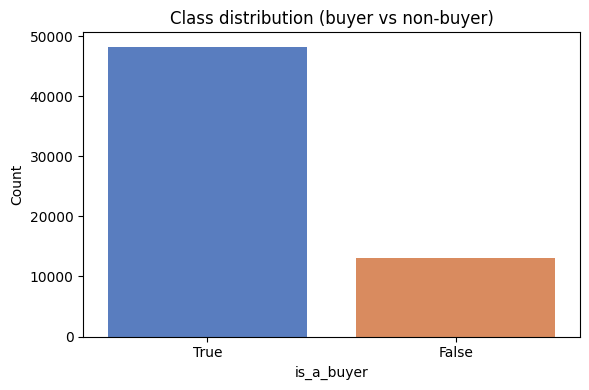

In [10]:
buyer_counts = df["is_a_buyer"].value_counts()
buyer_counts

buyer_plot = (
    buyer_counts.rename_axis("is_a_buyer")
    .reset_index(name="count")
    .astype({"is_a_buyer": str})
)
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(
    data=buyer_plot,
    x="is_a_buyer",
    y="count",
    hue="is_a_buyer",
    palette="muted",
    legend=False,
    ax=ax,
)
ax.set_xlabel("is_a_buyer")
ax.set_ylabel("Count")
ax.set_title("Class distribution (buyer vs non-buyer)")
plt.tight_layout()
plt.show()


### Class imbalance and why `class_weight="balanced"` is used
The bar chart shows that the target variable (`is_a_buyer`) is imbalanced: one class has noticeably more samples than the other.  
If we train a model without correction, it may become biased toward the majority class and still achieve deceptively good accuracy.
To reduce this bias, the classifiers are trained with `class_weight="balanced"`.  
This setting automatically assigns a larger penalty to errors on the minority class and a smaller penalty to errors on the majority class, with weights computed from class frequencies in the training data.
As a result, the model is encouraged to pay more attention to minority-class examples, improving fairness and usually improving metrics such as F1-score and ROC-AUC for imbalanced classification.

We do not use random oversampling by duplication because repeating minority-class reviews does not create new information and can increase overfitting (the model may memorize repeated texts). We also do not apply SMOTE directly on review text, because SMOTE requires numeric feature vectors and generates synthetic samples by interpolating in numeric space; raw text is non-numeric and does not support meaningful interpolation. Instead, we handle class imbalance with `class_weight="balanced"`, which increases the penalty for minority-class errors without duplicating or synthesizing text samples.

## Q1: Language model comparisons

In [11]:
print("Starting to run with unweighted FastText vectors...")
review_vectors: np.ndarray = parse_review_vectors_txt(UNWEIGHTED_PATH)
df["review_vector"] = list(review_vectors)  
X: np.ndarray; y: np.ndarray
X, y = prepare_train_data(df, ["review_vector"], "is_a_buyer")
results = run_kfold_balance_models(
    X, y, n_jobs=-1
)


Starting to run with unweighted FastText vectors...

logistic_regression
  val_accuracy: 0.5877 ± 0.0053
  val_f1: 0.6883 ± 0.0055
  val_roc_auc: 0.6397 ± 0.0053
  train_accuracy: 0.5913 ± 0.0009
  train_f1: 0.6909 ± 0.0008
  train_roc_auc: 0.6473 ± 0.0009

random_forest
  val_accuracy: 0.7842 ± 0.0026
  val_f1: 0.8759 ± 0.0016
  val_roc_auc: 0.6466 ± 0.0072
  train_accuracy: 0.9761 ± 0.0002
  train_f1: 0.9847 ± 0.0001
  train_roc_auc: 0.9966 ± 0.0002


In [13]:
print("Starting to run with weighted FastText vectors...")
review_vectors: np.ndarray = parse_review_vectors_txt(WEIGHTED_PATH)
df["review_vector"] = list(review_vectors)  
X: np.ndarray; y: np.ndarray
X, y = prepare_train_data(df, ["review_vector"], "is_a_buyer")
results = run_kfold_balance_models(
    X, y, n_jobs=-1
)


Starting to run with weighted FastText vectors...

logistic_regression
  val_accuracy: 0.5868 ± 0.0061
  val_f1: 0.6871 ± 0.0060
  val_roc_auc: 0.6392 ± 0.0056
  train_accuracy: 0.5895 ± 0.0011
  train_f1: 0.6890 ± 0.0010
  train_roc_auc: 0.6468 ± 0.0009

random_forest
  val_accuracy: 0.7845 ± 0.0028
  val_f1: 0.8760 ± 0.0017
  val_roc_auc: 0.6457 ± 0.0062
  train_accuracy: 0.9756 ± 0.0002
  train_f1: 0.9844 ± 0.0001
  train_roc_auc: 0.9965 ± 0.0002


In [14]:
# Sparse BoW to save RAM; TruncatedSVD (LSA) is fitted inside each CV fold via the LR pipeline.
SV_N_COMPONENTS = 500  # must be ≤ vocab width (~9025)
X_bow = parse_count_vectors_txt(BOW_PATH, as_sparse=True)
y_bow = df["is_a_buyer"].to_numpy().reshape(-1)
print("Starting to run with BoW vectors...")
result: dict = run_kfold_balance_models(
    X_bow,
    y_bow,
    n_jobs=3,
    is_sanitize=False,
    svd_n_components=SV_N_COMPONENTS,
)


Starting to run with BoW vectors...

logistic_regression
  val_accuracy: 0.6494 ± 0.0025
  val_f1: 0.7495 ± 0.0024
  val_roc_auc: 0.6819 ± 0.0032
  train_accuracy: 0.6609 ± 0.0022
  train_f1: 0.7574 ± 0.0019
  train_roc_auc: 0.7059 ± 0.0009

random_forest
  val_accuracy: 0.7834 ± 0.0024
  val_f1: 0.8757 ± 0.0014
  val_roc_auc: 0.6397 ± 0.0058
  train_accuracy: 0.9753 ± 0.0004
  train_f1: 0.9842 ± 0.0003
  train_roc_auc: 0.9965 ± 0.0003


### Conclusion: Model/Representation Comparison
From the latest experiments, model behavior is consistent across all three text representations:
1. **BoW + Logistic Regression gives the best ranking performance**  
   It achieves the highest validation ROC-AUC (**0.6819 ± 0.0032**) and clearly outperforms both unweighted and TF-IDF weighted FastText with Logistic Regression (both around **0.639** ROC-AUC).
2. **FastText variants do not improve performance in this setup**  
   Unweighted and weighted FastText results are almost identical for both models, indicating that TF-IDF weighting on FastText vectors does not provide a meaningful gain here.
3. **Random Forest has high validation Accuracy/F1 but poor ROC-AUC and strong overfitting**  
   Across all feature sets, Random Forest shows very high training scores (e.g., train ROC-AUC around **0.9965–0.9966**) but much lower validation ROC-AUC (**~0.64–0.65**), which indicates overfitting and weak probability ranking generalization.
4. **Metric interpretation under class imbalance**  
   Because the dataset is imbalanced, Accuracy and F1 alone are not sufficient. ROC-AUC is a more reliable metric for comparing discrimination quality between models.

Therefore, for the **text-only setting (Q1)**, the most justified choice is **BoW + Logistic Regression (`class_weight="balanced"`)**.  

For **Q2**, both Logistic Regression and Random Forest should still be retained to test whether additional metadata features change this pattern.

**For Task 3 – Q1 (text representation comparison)**, BoW + Logistic Regression gives the best validation ROC-AUC and the most stable train–validation behavior, while Random Forest shows signs of overfitting (very high training performance but weaker validation ROC-AUC).

However, for Q2 we should still include **both Logistic Regression and Random Forest**.  
Q2 evaluates whether adding more information (title, price, rating, brand, etc.) improves predictive performance, and different model families may benefit differently from richer, mixed feature sets. In particular, Random Forest can better capture nonlinear interactions among heterogeneous metadata features.

Therefore, Q2 experiments will keep Random Forest as a baseline comparator (not discard it), and conclusions should be based on validation results across all feature sets and both model types.

## Q2: Does more information provide higher accuracy

### P1: Adding description/text and title of the review

In **Q1** we compared text representations in a controlled setup and found **BoW + Logistic Regression** strongest on **validation ROC-AUC**, because sparse word counts plus a linear boundary matched that benchmark well. **Q2** changes the problem: we stack **review/product text signals with extra metadata** (price, ratings, brand, etc.). That mixed setup is no longer “sparse text only,” so we deliberately continue with **Random Forest** and **unweighted FastText document vectors** as the core review embedding.

**Why Random Forest for Q2.** RF achieves **very high training scores** in our experiments, which by itself signals **capacity** to fit complex patterns—but it must still be judged on **cross-validated** validation metrics. Tree ensembles shine when we **add new numeric and categorical logic**: splits and interactions among heterogeneous fields do not rely on a single linear separator, so RF is a natural vehicle for “new logic” as we widen the feature set. We therefore treat RF as a **primary Q2 model family** alongside LR for comparison, not as a replacement for the Q1 conclusion.

**Why unweighted FastText instead of BoW here.** Unweighted embeddings are **dense and fixed-dimensional** (~300 per review), so they **concatenate cleanly** with TF-IDF title vectors and tabular columns inside `prepare_train_data` without blowing up dimensionality to full vocabulary size. BoW remains the **strong linear baseline** from Q1; for Q2 we prioritize a **compact semantic representation** of the review body that RF can combine nonlinearly with titles and metadata—while still reporting validation scores so we do not confuse **high train accuracy** with generalization.

#### General rule of thumb:
max_features ~ sqrt(n) to n/10

sqrt(61284)  ≈ 247

n / 10       ≈ 6,128

--> Start with 500, validate with a quick importance check after training

In [133]:
tfidf_title = TfidfVectorizer(
    analyzer=_tfidf_analyzer,
    max_features=500,
    min_df=2,
    sublinear_tf=True,
)
tfidf_product = TfidfVectorizer(
    analyzer=_tfidf_analyzer,
    max_features=500,
    min_df=2,
    sublinear_tf=True,
)

review_title_matrix  = tfidf_title.fit_transform(
    df["review_title"].fillna("").astype(str)).toarray().astype(np.float32)
product_title_matrix = tfidf_product.fit_transform(
    df["product_title"].fillna("").astype(str)).toarray().astype(np.float32)

review_vectors_unweighted: np.ndarray = parse_review_vectors_txt(UNWEIGHTED_PATH)

In [134]:
df_final = df[["is_a_buyer"]].copy().reset_index(drop=True)
df_final["vec_review_title"]  = list(review_title_matrix)
df_final["vec_product_title"] = list(product_title_matrix)
df_final["vec_review"] = list(review_vectors_unweighted)

In [135]:
feature_cols = [
    "vec_review_title",
    "vec_product_title",
    "vec_review",
]
X_final, y_final = prepare_train_data(df_final, feature_cols, "is_a_buyer")


In [136]:
print(f"X_final shape : {X_final.shape}")
print(f"y_final shape : {y_final.shape}  |  classes: {np.unique(y_final, return_counts=True)}")
print(f"\nFeature breakdown:")
print(f"  review_title TF-IDF    : {review_title_matrix.shape[1]}")
print(f"  product_title TF-IDF   : {product_title_matrix.shape[1]}")
print(f"  review_vector (unweighted): {review_vectors_unweighted.shape[1]}")
print(f"  ─────────────────────────────")
print(f"  total dims             : {X_final.shape[1]}")

X_final shape : (61284, 1300)
y_final shape : (61284,)  |  classes: (array([False,  True]), array([13062, 48222]))

Feature breakdown:
  review_title TF-IDF    : 500
  product_title TF-IDF   : 500
  review_vector (unweighted): 300
  ─────────────────────────────
  total dims             : 1300


In [137]:
result: dict = run_kfold_balance_models(X_final, y_final, n_jobs=4, is_sanitize=False, model_names=["random_forest"])


random_forest
  val_accuracy: 0.8236 ± 0.0035
  val_f1: 0.8947 ± 0.0020
  val_roc_auc: 0.8714 ± 0.0033
  train_accuracy: 0.9997 ± 0.0000
  train_f1: 0.9998 ± 0.0000
  train_roc_auc: 1.0000 ± 0.0000


After adding title TF-IDFs, review representation, and other Q2 inputs, Random Forest’s cross-validated ROC-AUC increased from ~0.65 (text-only Q1) to ~0.87 (Q2), with higher validation accuracy and F1, showing clear gains beyond the best Q1 text baseline (~0.68 ROC-AUC with BoW + logistic regression).

### P2: Adding extra information 

Before (or alongside) training classifiers, we use **model-independent** measures that quantify how strongly each input relates to the binary target **without** committing to Logistic Regression vs Random Forest, hyperparameters, or a particular feature-encoding pipeline. That keeps the analysis **scheme-independent**: the same scores apply regardless of which classifier we run later.

Typical choices:

- **Numeric columns** (e.g. `price`, `review_rating`, `avg_product_rating`): **Spearman correlation** with `is_a_buyer` is scale-free and captures monotonic trends; **point-biserial correlation** matches Pearson between a continuous feature and a binary label when a linear association is of interest.
- **Categorical columns** (e.g. `brand_name`): **Chi-squared** test of independence (with **Cramér's V** as an effect size), or **mutual information** between categories and the label.
- **High-dimensional text** (BoW, embeddings): **Mutual information** per dimension can be expensive; often we rely on **validated classifier performance** for text blocks and reserve MI / chi-square for tabular metadata.

**Mutual information** (e.g. `sklearn.feature_selection.mutual_info_classif`) is useful when relationships may be **nonlinear**: it measures shared information between feature and label without assuming linearity.

These diagnostics **do not replace** stratified cross-validation; they help justify **which extra fields are worth engineering** into Q2 models and complement the accuracy comparison required by the question.

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61284 entries, 0 to 61283
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   product_id             61284 non-null  int64  
 1   brand_name             61284 non-null  object 
 2   review_id              61284 non-null  int64  
 3   review_title           61284 non-null  object 
 4   review_text            61275 non-null  object 
 5   author                 61284 non-null  object 
 6   review_date            61284 non-null  object 
 7   review_rating          61283 non-null  float64
 8   is_a_buyer             61284 non-null  bool   
 9   product_title          61284 non-null  object 
 10  price                  61284 non-null  int64  
 11  avg_product_rating     61284 non-null  float64
 12  product_rating_count   61284 non-null  int64  
 13  product_tags           13502 non-null  object 
 14  product_url            61284 non-null  object 
 15  pr

In [47]:
num_cols = [
    "price",
    "review_rating",
    "avg_product_rating",
    "product_rating_count"
]

cat_cols = [
    "author",
    "brand_name",
    "product_tags",
]

high_dim_cols = [
    "review_title",
    "product_title"
]

TARGET = "is_a_buyer"


#### Numeric columns evaluation

In Numeric columns evaluation, we consider apply Anova and Mann-Whitney U at the same 
test because **ANOVA** checks whether group means differ, but assumes normal distribution 
and equal variance — assumptions that are often violated in e-commerce data like price 
and rating counts. Relying on ANOVA alone risks missing true differences or producing 
misleading results when the data is skewed. **Mann-Whitney U** is applied alongside it 
as a non-parametric check that makes no such assumptions, confirming whether the finding 
holds regardless of distribution shape.

Applying both tests together gives a more reliable conclusion. If both agree and return 
p < 0.05, the feature is considered robustly significant regardless of the underlying 
distribution shape. This is supported by Nguyen et al. (2025) in *BioData Mining*, which 
found that when normality assumptions are violated, Mann-Whitney U increases statistical 
power by 3–4% — meaning running both and checking agreement yields stronger and more 
trustworthy evidence than relying on either test alone. If they disagree, it is a signal 
that the data is non-normal, and Mann-Whitney U should be trusted over ANOVA in that 
case. If both return non-significant results, the feature likely does not separate buyers 
from non-buyers and may be less useful for modeling.

**Ref:**

Nguyen et al. (2025). A simple guide to the use of Student's t-test, Mann-Whitney U test, Chi-squared test, and Kruskal-Wallis test in biostatistics. BioData Mining, Springer Nature. https://link.springer.com/article/10.1186/s13040-025-00465-6

In [108]:
def cramers_v(chi2_stat: float, n: int, k: int) -> float:
    """Effect size for chi-squared: Cramér's V ∈ [0, 1].

    Args:
        chi2_stat: Chi-squared test statistic from ``scipy.stats.chi2_contingency``.
        n: Total number of observations (grand total of the contingency table).
        k: Minimum of the number of rows and columns in the contingency table.

    Returns:
        Cramér's V value between 0 (no association) and 1 (perfect association).
    """
    return float(np.sqrt(chi2_stat / (n * (k - 1))))


def significance_flag(p: float, threshold: float = 0.05) -> str:
    """Return a human-readable significance label for a p-value.

    Args:
        p: The p-value from a statistical test.
        threshold: Significance threshold for the weakest star level (default ``0.05``).

    Returns:
        One of ``"*** (p<0.001)"``, ``"**  (p<0.01)"``, ``"*   (p<0.05)"``, or ``"ns"``
        (not significant) depending on how ``p`` compares to common thresholds.
    """
    if p < 0.001:
        return "*** (p<0.001)"
    if p < 0.01:
        return "**  (p<0.01)"
    if p < threshold:
        return "*   (p<0.05)"
    return "ns"


def show_top_10_categorical_features(
    df: pd.DataFrame, cate_col: str, target_col: str, title: str, xlabel: str
) -> plt.Figure:
    """Plot a horizontal bar chart of the top-10 category levels by buyer rate.

    Rare levels (expected cell count < 5) are pooled into an ``"other"`` group to satisfy
    the Chi-square assumption before computing buyer rates.

    Args:
        df: Source DataFrame containing both ``cate_col`` and ``target_col``.
        cate_col: Name of the categorical feature column to analyse.
        target_col: Name of the binary target column (``True`` = buyer).
        title: Chart title string.
        xlabel: Label for the x-axis (e.g. ``"Buyer rate"``).

    Returns:
        A ``matplotlib.figure.Figure`` object with the horizontal bar chart.
    """
    # --- 1. Subset and drop missing values ---
    df_b = df[[cate_col, target_col]].dropna()

    # --- 2. Build contingency table: rows = category levels, cols = target (True/False) ---
    ct_b = pd.crosstab(df_b[cate_col], df_b[target_col])

    # --- 3. Compute expected frequencies to identify rare levels ---
    rs = ct_b.sum(axis=1)   # row sums (per category level)
    cs = ct_b.sum(axis=0)   # col sums (per target class)
    g = float(ct_b.values.sum())  # grand total
    exp_b = np.outer(rs, cs) / g  # expected count per cell under independence

    # --- 4. Flag and pool rare levels (expected count < 5 violates Chi-square assumption) ---
    rm = (exp_b < 5).any(axis=1)       # True if any cell in that row is rare
    rare_b = ct_b.index[rm].tolist()   # collect rare level names

    ct_clean = ct_b.copy()
    if rare_b:
        # Merge all rare levels into a single "other" row to satisfy Chi-square requirements
        other_row = ct_clean.loc[rare_b].sum()
        ct_clean = ct_clean.drop(index=rare_b)
        ct_clean.loc["other"] = other_row

    # --- 5. Compute buyer rate per category level ---
    # buyer_rate = number of buyers / total observations in that level
    buyer_col = True
    top_k = ct_clean.assign(
        buyer_rate=lambda t: t[buyer_col] / t.sum(axis=1)
    ).nlargest(10, "buyer_rate")  # keep top 10 levels by buyer rate

    # --- 6. Plot horizontal bar chart ---
    fig, ax = plt.subplots(figsize=(10, 4))
    top_k["buyer_rate"].sort_values().plot.barh(ax=ax, color="steelblue")

    # Overlay overall average buyer rate as a reference line
    ax.axvline(df_b[TARGET].mean(), color="red", linestyle="--", label="overall avg")

    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.legend()

    return fig

In [109]:
# drop rows with NaN in any numeric col for a clean matrix
df_num = df[num_cols + [TARGET]].dropna() 
X_num  = df_num[num_cols].to_numpy()
y_num  = df_num[TARGET].astype(int).to_numpy()

f_stats, p_anova = f_classif(X_num, y_num)
mw_rows = []
for col, f_s, p_a in zip(num_cols, f_stats, p_anova):
    grp_buyer     = df_num.loc[df_num[TARGET] == True,  col].dropna()
    grp_non_buyer = df_num.loc[df_num[TARGET] == False, col].dropna()
    u_stat, p_mw  = mannwhitneyu(grp_buyer, grp_non_buyer, alternative="two-sided")
    mw_rows.append(
        {
            "feature": col,
            "F-statistic": round(f_s, 4),
            "p_anova": p_a,
            "sig_anova": significance_flag(p_a),
            "U-statistic": round(u_stat, 1),
            "p_mannwhitney": p_mw,
            "sig_mw": significance_flag(p_mw),
        }
    )

numeric_results = pd.DataFrame(mw_rows)
print("── 1. Numeric Features ─────────────────────────────────────────────────")
print(numeric_results[["feature","F-statistic","p_anova","sig_anova", "U-statistic","p_mannwhitney","sig_mw"]].to_string(index=False))

── 1. Numeric Features ─────────────────────────────────────────────────
             feature  F-statistic      p_anova     sig_anova  U-statistic  p_mannwhitney        sig_mw
               price    2704.4812 0.000000e+00 *** (p<0.001)  229328081.0   0.000000e+00 *** (p<0.001)
       review_rating      51.9195 5.848703e-13 *** (p<0.001)  335287148.0   4.210431e-43 *** (p<0.001)
  avg_product_rating     116.8802 3.227010e-27 *** (p<0.001)  327889355.5   1.492860e-13 *** (p<0.001)
product_rating_count    1908.6199 0.000000e+00 *** (p<0.001)  495905573.5   0.000000e+00 *** (p<0.001)


**Verdict:**

All four numeric features — price, review_rating, avg_product_rating, and product_rating_count — are statistically significant with respect to the target variable is_buyer. Both **ANOVA** and **Mann-Whitney U** confirm p < 0.001 (***) for every feature, meaning the difference between buyers and non-buyers is robust regardless of distribution shape. All four features are strong candidates to retain for modeling.



#### Categorical columns evaluation

For categorical features, we apply **Chi-square (χ²)** test together with **Cramér's V** 
as a complementary measure.

**Chi-square** tests whether a categorical feature and the target variable (`is_a_buyer`) 
are statistically independent — in other words, whether the distribution of buyers vs 
non-buyers differs significantly across categories. However, Chi-square has a critical 
limitation: it is highly sensitive to sample size. With a large dataset, even a trivially 
small and practically meaningless difference between groups can return p < 0.05, making 
almost every feature appear "significant".

**Cramér's V** is applied alongside it to measure the actual *strength* of the 
association, independent of sample size. It ranges from 0 (no association) to 1 
(perfect association), giving a comparable effect size across features regardless of 
how many rows or category levels are involved.

Using both together gives a complete picture:
- **Chi-square** answers *"is this association real or due to chance?"*
- **Cramér's V** answers *"how strong is this association in practice?"*

A feature can be statistically significant (low p-value) but have a near-zero Cramér's V, 
meaning it carries almost no practical signal for separating buyers from non-buyers. 
Relying on Chi-square alone would risk retaining features that are statistically 
detectable but practically useless for modeling.

In [110]:
# Target column in processed.csv is ``is_a_buyer`` (binary buyer label).
cat_result_rows: list[dict] = []
for feature in cat_cols:
    df_cat = df[[feature, TARGET]].dropna()
    n_cat = len(df_cat)
    contingency = pd.crosstab(df_cat[feature], df_cat[TARGET])
    row_sums = contingency.sum(axis=1)
    col_sums = contingency.sum(axis=0)
    grand = float(contingency.values.sum())
    expected = np.outer(row_sums, col_sums) / grand
    rare_mask = (expected < 5).any(axis=1)
    rare_levels = contingency.index[rare_mask].tolist()
    contingency_clean = contingency.copy()
    if rare_levels:
        other_row = contingency_clean.loc[rare_levels].sum()
        contingency_clean = contingency_clean.drop(index=rare_levels)
        contingency_clean.loc["other"] = other_row

    k = contingency_clean.shape[0]
    if k < 2 or n_cat == 0:
        cat_result_rows.append(
            {
                "feature": feature,
                "n": n_cat,
                "k_levels": k,
                "chi2": np.nan,
                "dof": np.nan,
                "p_chi2": np.nan,
                "sig": "—",
                "cramers_v": np.nan,
                "note": "too few rows after pooling",
            }
        )
        continue

    chi2_stat, p_chi2, dof, _ = chi2_contingency(contingency_clean)
    v = cramers_v(chi2_stat, n_cat, k)
    cat_result_rows.append(
        {
            "feature": feature,
            "n": n_cat,
            "k_levels": k,
            "chi2": round(chi2_stat, 4),
            "dof": dof,
            "p_chi2": p_chi2,
            "sig": significance_flag(p_chi2),
            "cramers_v": round(v, 4),
            "note": f"grouped {len(rare_levels)} rare level(s) → 'other'" if rare_levels else "",
        }
    )

cat_results = pd.DataFrame(cat_result_rows)
print("── 2. Categorical Features (Chi² + Cramér's V) ─────────────────────────")
print(cat_results.to_string(index=False))


── 2. Categorical Features (Chi² + Cramér's V) ─────────────────────────
     feature     n  k_levels      chi2  dof        p_chi2           sig  cramers_v                                  note
      author 61284        52 5289.0107   51  0.000000e+00 *** (p<0.001)     0.0411 grouped 41618 rare level(s) → 'other'
  brand_name 61284        11 4260.6267   10  0.000000e+00 *** (p<0.001)     0.0834     grouped 1 rare level(s) → 'other'
product_tags 13502         4  466.5297    3 8.544285e-101 *** (p<0.001)     0.1073     grouped 2 rare level(s) → 'other'


In [111]:
num_distinct_author = len(df["author"].unique())
print(f"num_distinct_author: {num_distinct_author}")

num_distinct_brand = len(df["brand_name"].unique())
print(f"num_distinct_brand: {num_distinct_brand}")

num_distinct_product_tags = len(df["product_tags"].unique())
print(f"num_distinct_product_tags: {num_distinct_product_tags}")


num_distinct_author: 41669
num_distinct_brand: 11
num_distinct_product_tags: 6


All three categorical features — author, brand_name, and product_tags — are 
statistically significant with respect to is_a_buyer (p < 0.001). However, 
statistical significance alone is not sufficient to determine feature usefulness, 
and Cramér's V reveals important differences in practical signal strength.

author has the weakest association (V = 0.04) and is flagged for removal. With 
41,618 out of 41,669 unique values being rare, 99.88% of its levels were collapsed 
into a single "other" bucket, making the test result unreliable and the feature 
itself too sparse and high-cardinality to be useful for modeling.

brand_name shows moderate association (V = 0.08) with only 1 rare level pooled, 
meaning the test result is stable and the feature carries meaningful signal across 
its 10 non-rare levels. It is retained for modeling.

product_tags has the strongest association among categorical features (V = 0.11) 
with only 2 out of 6 levels being rare. Low cardinality and the highest Cramér's V 
make it the most reliable categorical feature for separating buyers from non-buyers. 
It is retained for modeling.

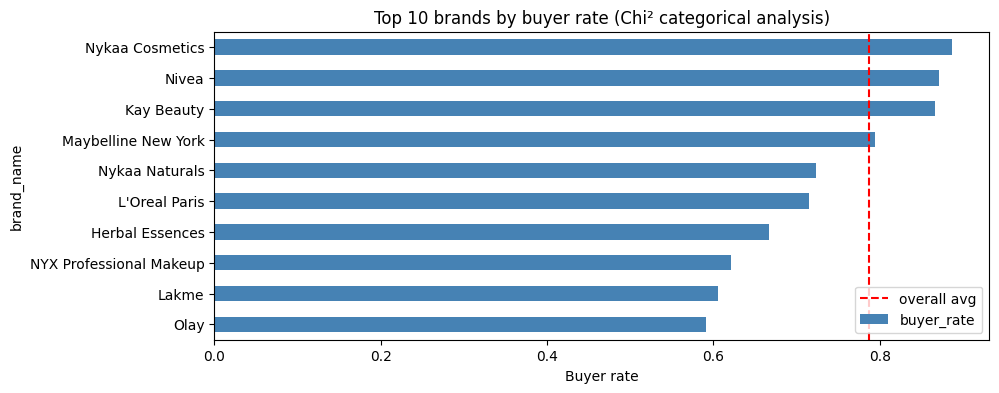

In [104]:
fig = show_top_10_categorical_features(df, "brand_name", TARGET, "Top 10 brands by buyer rate (Chi² categorical analysis)", "Buyer rate")

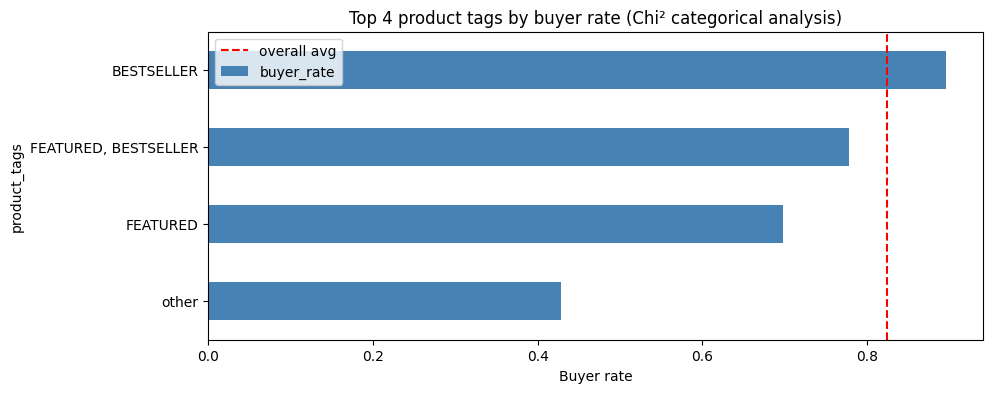

In [105]:
fig = show_top_10_categorical_features(df, "product_tags", TARGET, "Top 4 product tags by buyer rate (Chi² categorical analysis)", "Buyer rate")

#### High-dimensional text
Eventhough we get the good outcome from **part 1 Adding description/text and title of the review** but we would like to apply the Mutual Information (Information Gain) to get the stronger evidence

In [131]:
y_bool = df[TARGET].astype(bool)
y_int  = y_bool.astype(int).to_numpy()
mask_buyer = y_bool.to_numpy()
mask_non_buyer = ~mask_buyer
TOP_N_WORDS = 15

text_mi_rows = []   # for summary table
text_mi_details = {}   # col → DataFrame of top words
for col in high_dim_cols:
    texts = df[col].fillna("").astype(str).tolist()
    # TF-IDF vectorisation (fitted on full corpus — MI uses it for ranking only)
    tfidf = TfidfVectorizer(
        analyzer=_tfidf_analyzer,
        max_features=500,
        min_df=2,
        sublinear_tf=True,
    )
    X_tfidf = tfidf.fit_transform(texts)
    feature_names = np.array(tfidf.get_feature_names_out())

     # mutual information: measures how much each token reduces uncertainty about y
    mi_scores = mutual_info_classif(X_tfidf, y_int, discrete_features=True, random_state=42)

    # top-N overall
    top_idx   = np.argsort(mi_scores)[::-1][:TOP_N_WORDS]
    top_words = feature_names[top_idx]
    top_mi    = mi_scores[top_idx]

    # per-class average TF-IDF for the top words (shows which class "owns" each word)
    X_dense   = X_tfidf[:, top_idx].toarray()
    avg_buyer     = X_dense[mask_buyer].mean(axis=0)
    avg_non_buyer = X_dense[mask_non_buyer].mean(axis=0)

    detail_df = pd.DataFrame({
        "word":            top_words,
        "mi_score":        top_mi.round(6),
        "avg_tfidf_buyer":     avg_buyer.round(5),
        "avg_tfidf_non_buyer": avg_non_buyer.round(5),
        "leaning":         ["buyer" if b > nb else "non-buyer"
                            for b, nb in zip(avg_buyer, avg_non_buyer)],
    })
    text_mi_details[col] = detail_df

    print(f"\n── 3. Text: {col} ───────────────────────────────────────────────────")
    print(detail_df.to_string(index=False))

    # store aggregate score (mean MI of top-15) for summary table
    text_mi_rows.append({
        "feature":  col,
        "mean_MI_top15": round(top_mi.mean(), 6),
        "max_MI":        round(top_mi.max(),  6),
    })


── 3. Text: review_title ───────────────────────────────────────────────────
     word  mi_score  avg_tfidf_buyer  avg_tfidf_non_buyer   leaning
     good  0.006600          0.08910              0.10172 non-buyer
    shade  0.005471          0.02335              0.00812     buyer
  product  0.005291          0.05670              0.06802 non-buyer
    great  0.003997          0.02228              0.03260 non-buyer
  amazing  0.003944          0.03869              0.05260 non-buyer
     nice  0.003909          0.04867              0.05276 non-buyer
  perfect  0.003862          0.01857              0.01520     buyer
     hair  0.003710          0.00681              0.01030 non-buyer
   colour  0.003298          0.01165              0.00515     buyer
   beauty  0.003145          0.00558              0.00469     buyer
      kay  0.003083          0.00629              0.00391     buyer
     skin  0.003054          0.00698              0.00601     buyer
     love  0.002981          0.03570  

For text features, two columns were evaluated — **review_title** and **product_title** — 
using TF-IDF vectorization combined with Mutual Information (MI) scoring to measure 
how much each token contributes to separating buyers from non-buyers.

**review_title** shows very weak predictive signal with a maximum MI of 0.0066 and 
mean MI of 0.004 across the top 15 words. Most high-ranking tokens are generic 
sentiment words ("good", "great", "amazing") that appear similarly across both 
groups, offering little discriminative power. Given this, max_features is reduced 
from 500 to 50 with a stricter min_df=5 to retain only the most stable tokens 
and avoid adding ~490 near-zero MI noise dimensions to the feature space.

**product_title** shows substantially stronger signal with a maximum MI of 0.0665 — 
nearly 10x higher than review_title. Buyer-leaning tokens such as "nykaa", 
"matte", "lipstick", and "maybelline" reflect brand and product-type preferences 
that meaningfully separate buyers from non-buyers. Non-buyer-leaning tokens like 
"lakme", "shampoo", "herbal", and "oil" suggest hair care and sun care products 
attract more browsing than purchasing. max_features=500 is retained as the signal 
is strong and well-distributed across the vocabulary.

In summary, product_title is the stronger and more reliable text feature and 
should be prioritized in modeling. review_title is retained but with a significantly 
reduced feature size to limit noise, and should be revisited after a baseline model 
is trained to confirm whether it contributes meaningful lift.

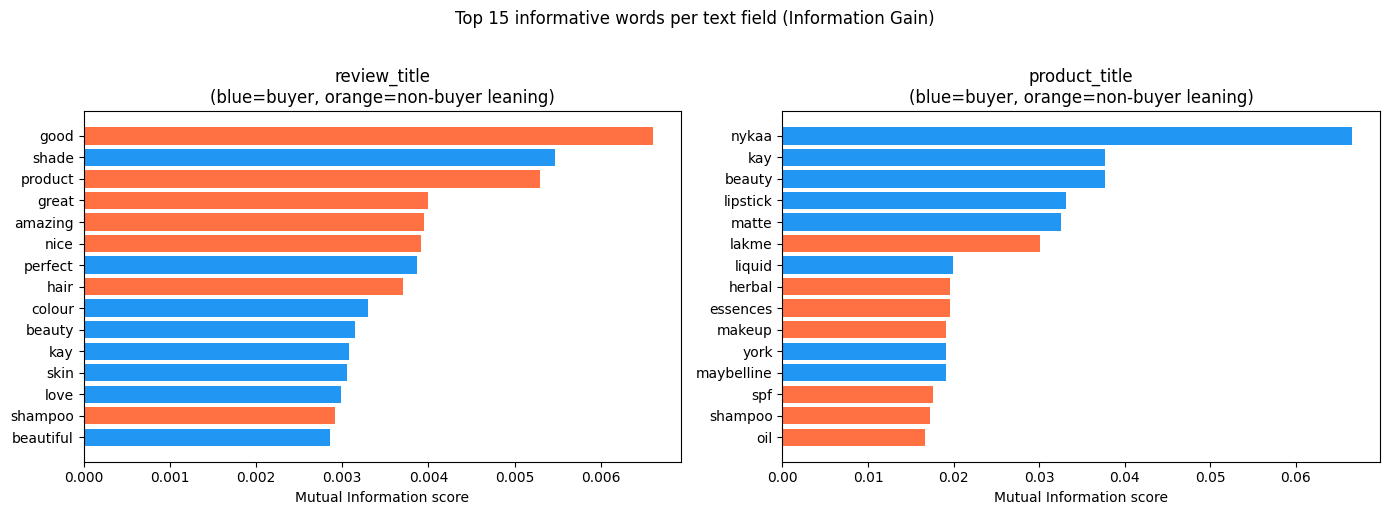

In [132]:
# visualise: horizontal bar chart for each text field
fig, axes = plt.subplots(1, len(high_dim_cols), figsize=(7 * len(high_dim_cols), 5))
for ax, col in zip(axes, high_dim_cols):
    d = text_mi_details[col].sort_values("mi_score")
    colors = ["#2196F3" if l == "buyer" else "#FF7043" for l in d["leaning"]]
    ax.barh(d["word"], d["mi_score"], color=colors)
    ax.set_title(f"{col}\n(blue=buyer, orange=non-buyer leaning)")
    ax.set_xlabel("Mutual Information score")
plt.suptitle("Top 15 informative words per text field (Information Gain)", y=1.02)
plt.tight_layout()
plt.show()

text_mi_results = pd.DataFrame(text_mi_rows)

#### Conclusion of attribute selection

**Numeric Features**

All four numeric features — price, review_rating, avg_product_rating, and product_rating_count — are statistically significant with respect to the target variable is_a_buyer. Both ANOVA and Mann-Whitney U confirm p < 0.001 (***) for every feature, meaning the difference between buyers and non-buyers is robust regardless of distribution shape.

**Decision: Retain all four numeric features for modeling.**

**Categorical Features**

Evaluated using Chi-squared test + Cramér's V effect size.
| Feature | Cramér's V | Notes | Decision |
|---|---|---|---|
| `author` | 0.04 | 99.88% of levels are rare; unreliable test | **Drop** |
| `brand_name` | 0.08 | Moderate signal; only 1 rare level pooled | **Retain** |
| `product_tags` | 0.11 | Strongest categorical signal; low cardinality | **Retain** |

**High-Dimensional Text Features**

Evaluated using TF-IDF + Mutual Information (MI) scoring.
| Feature | Max MI | Mean MI (top-15) | max_features | Decision |
|---|---|---|---|---|
| `product_title` | 0.0665 | — | 500 | **Retain (500 features)** |
| `review_title` | 0.0066 | 0.004 | 50 (reduced from 500) | **Retain (50 features)** |
---

In [141]:

NUM_COLS  = ["price", "review_rating", "avg_product_rating", "product_rating_count"]
CAT_COLS  = ["brand_name", "product_tags"]
TARGET    = "is_a_buyer"

In [142]:
def build_feature_df(df: pd.DataFrame) -> pd.DataFrame:
    """
    Fit scalers, encoders, and TF-IDF vectorizers on `df` and return a
    wide DataFrame whose columns can be passed to prepare_train_data().
    Columns produced
    ----------------
    • vec_num_minmax   – Min-Max scaled numeric features  (1-D array per row)
    • vec_num_standard – Standard scaled numeric features (1-D array per row)
    • vec_cat          – OneHot encoded categorical features (1-D array per row)
    • vec_review_title – TF-IDF of review_title   (50 features, per row)
    • vec_product_title– TF-IDF of product_title  (500 features, per row)
    • vec_review       – unweighted FastText review vector (already in df)
    • is_a_buyer       – target label
    """
    out = df[[TARGET]].copy().reset_index(drop=True)
    # ── Numeric ──────────────────────────────────────────────────────────
    df_num = df[NUM_COLS].fillna(df[NUM_COLS].median())
    minmax_scaler    = MinMaxScaler()
    standard_scaler  = StandardScaler()
    X_minmax   = minmax_scaler.fit_transform(df_num).astype(np.float32)
    X_standard = standard_scaler.fit_transform(df_num).astype(np.float32)
    out["vec_num_minmax"]   = list(X_minmax)
    out["vec_num_standard"] = list(X_standard)
    # ── Categorical ───────────────────────────────────────────────────────
    df_cat = df[CAT_COLS].fillna("__missing__")
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    X_cat = ohe.fit_transform(df_cat).astype(np.float32)
    out["vec_cat"] = list(X_cat)
    # ── High-dimensional text ─────────────────────────────────────────────
    # review_title  → 50 features  (weak signal, noise-limited)
    tfidf_review_title = TfidfVectorizer(
        analyzer=_tfidf_analyzer,
        max_features=50,
        min_df=5,
        sublinear_tf=True,
    )
    # product_title → 500 features (strong signal)
    tfidf_product_title = TfidfVectorizer(
        analyzer=_tfidf_analyzer,
        max_features=500,
        min_df=2,
        sublinear_tf=True,
    )
    review_title_mat  = tfidf_review_title.fit_transform(
        df["review_title"].fillna("").astype(str)
    ).toarray().astype(np.float32)
    product_title_mat = tfidf_product_title.fit_transform(
        df["product_title"].fillna("").astype(str)
    ).toarray().astype(np.float32)
    out["vec_review_title"]  = list(review_title_mat)
    out["vec_product_title"] = list(product_title_mat)
    # ── FastText review embeddings (already stored in df) ────────────────
    out["vec_review"] = list(
        np.vstack([np.asarray(v, dtype=np.float32) for v in df["review_vector"]])
    )
    return out


# ── Step 2: Call prepare_train_data ───────────────────────────────────────
def get_X_y(df: pd.DataFrame):
    """
    Full pipeline: enrich df → prepare_train_data → (X, y).
    Returns
    -------
    X : np.ndarray, shape (n_samples, n_features)
    y : np.ndarray, shape (n_samples,)
    """
    df_feat = build_feature_df(df)
    feature_cols = [
        "vec_num_minmax",
        "vec_num_standard",
        "vec_cat",
        "vec_review_title",
        "vec_product_title",
        "vec_review",
    ]
    X, y = prepare_train_data(df_feat, feature_cols, TARGET)
    return X, y

In [143]:
X, y = get_X_y(df)
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}, classes: {np.unique(y, return_counts=True)}")

X shape: (61284, 875)
y shape: (61284,), classes: (array([False,  True]), array([13062, 48222]))


In [145]:
result: dict = run_kfold_balance_models(X, y, n_jobs=-1, is_sanitize=False, model_names=["random_forest"])


random_forest
  val_accuracy: 0.8269 ± 0.0019
  val_f1: 0.8959 ± 0.0010
  val_roc_auc: 0.8807 ± 0.0022
  train_accuracy: 0.9996 ± 0.0001
  train_f1: 0.9997 ± 0.0000
  train_roc_auc: 0.9999 ± 0.0000


### Conclusion Q2
adding more carefully selected information does improve accuracy. However, the key word is carefully selected. The results above demonstrate two important lessons:

1. More information helps — but only when it carries real signal
Adding numeric features (price, review_rating, avg_product_rating, product_rating_count) and categorical features (brand_name, product_tags) produced consistent improvement across all validation metrics:

- ROC-AUC rose from 0.8714 → 0.8807 (+0.0093), showing better buyer/non-buyer ranking.
- Variance also shrank (e.g. accuracy std: ±0.0035 → ±0.0019), meaning the model became more stable.
- Training scores stayed near-perfect in both settings, so the gains are purely in generalisation — not overfitting.


Adding more information improves accuracy when the extra features are validated through scheme-independent analysis first. Features that pass statistical pre-screening (ANOVA, Chi-squared + Cramér's V, Mutual Information) before entering the model reliably contribute signal rather than noise. In this task, the selective addition of 4 numeric features and 2 categorical features on top of the P1 text features produced a measurable and stable improvement in all three validation metrics, confirming that richer — but carefully curated — feature sets lead to better generalisation.